# Week 11 - Supervised machine learning: classification of basalt source

### Machine learning
Text from: https://scikit-learn.org/stable/tutorial/basic/tutorial.html

In general, a learning problem considers a set of n samples of data and then tries to predict properties of unknown data. If each sample is more than a single number and, for instance, a multi-dimensional entry (aka multivariate data), it is said to have several attributes or features.

Learning problems fall into a few categories:
- **supervised learning**, in which the data comes with additional attributes that we want to predict (https://scikit-learn.org/stable/supervised_learning.html). This problem can be either:
    - *regression*: if the desired output consists of one or more continuous variables, then the task is called regression. An example of a regression problem would be the prediction of the length of a salmon as a function of its age and weight.
    - *classification*: samples belong to two or more classes and we want to learn from already labeled data how to predict the class of unlabeled data. An example of a classification problem would be handwritten digit recognition, in which the aim is to assign each input vector to one of a finite number of discrete categories. Another way to think of classification is as a discrete (as opposed to continuous) form of supervised learning where one has a limited number of categories and for each of the n samples provided, one is to try to label them with the correct category or class.

- **unsupervised learning**, in which the training data consists of a set of input vectors x without any corresponding target values. The goal in such problems may be to discover groups of similar examples within the data, where it is called clustering, or to determine the distribution of data within the input space, known as density estimation, or to project the data from a high-dimensional space down to two or three dimensions for the purpose of visualization (https://scikit-learn.org/stable/unsupervised_learning.html).

### Training set and testing set

Machine learning is about learning some properties of a data set and then testing those properties against another data set. A common practice in machine learning is to evaluate an algorithm by splitting a data set into two. We call one of those sets the training set, on which we learn some properties; we call the other set the testing set, on which we test the learned properties.

**Today we will focus on classification through a supervised learning approach**

*Systems doing this type of analysis are all around us. Consider a spam filter for example*

# Classifying volcanic rocks

<img src="./figures/volcanic-tectonics.png" width = 600 align = 'center'>

Today we are going to deal with igneous geochemistry data. Igneous rocks are those that crystallize from cooling magma. Different magmas have different compositions associated with their origin and tectonic setting. During class today, we will focus on data from mafic lava flows (these are called basalts) as their chemistry *might* reflect the tectonic setting that they formed in.

> Igneous rocks form in a wide variety of tectonic settings,
including mid-ocean ridges, ocean islands, and volcanic
arcs. It is a problem of great interest to igneous petrologists
to recover the original tectonic setting of mafic rocks of the
past. When the geological setting alone cannot unambiguously
resolve this question, the chemical composition of
these rocks might contain the answer. The major, minor,
and trace elemental composition of basalts shows large
variations, for example as a function of formation depth
(e.g., Kushiro and Kuno, 1963) --- *Vermeesch (2006)*

For this analysis, we are going to use a dataset that was compiled in the following paper: 

Doucet et al. (2022) Geochemical fingerprinting of continental and oceanic basalts: A machine learning approach, *Earth-Science Reviews*  https://doi.org/10.1016/j.earscirev.2022.104192

These data were grouped into several different categories, we will focus our analysis onto three specific tectonic settings:

- 2452 ***Island arc basalts (ARC-O)*** from regions such as the Aeolian, Izu-Bonin, Kermadec, Kurile, Lesser Antilles, Mariana, Scotia, and Tonga arcs.
- 10555 ***Mid-ocean ridge (MORB)*** samples from the East Pacific Rise, Mid Atlantic Ridge, Indian Ocean, and Juan de Fuca Ridge.
- 8801 ***Ocean-island (OIB)*** samples from St. Helena, the Canary, Cape Verde, Caroline, Crozet, Hawaii-Emperor, Juan Fernandez, Marquesas, Mascarene, Samoan, and Society islands.

Have a look at the illustration above and determine where each of these settings are within the context of plate tectonics.

In [6]:
# As before we'll load in our three main packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# We'll also load several different classes from sklearn - these will be used for the different machine learning approaches we'll test
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Exercise 1 - Import data and inspect the geochemistry


The data are from the supplementary materials of the Doucet et al. (2022) paper. The samples are grouped by the type: MORB, OIB, and ARC-O etc..

In [7]:
## Load the file data/Vermeesch2006.csv of the basalt data into a pandas DataFrame
basalt_data = pd.read_csv("data/Doucet2022.csv", header = 11)
basalt_data.head()

,X1,type,location,SiO2,TiO2,Al2O3,FeOt,MgO,MnO,CaO,...,Ho,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U
0,26,ARC-C,ANDEAN-ARC-1,46.4,0.54,11.72,11.92,19.60,0.20,5.26,...,0.26,0.8,0.11,0.6,0.10,NaN,NaN,NaN,NaN,NaN
1,27,ARC-C,ANDEAN-ARC-1,45.8,0.64,10.63,11.79,21.40,0.19,5.07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28,ARC-C,ANDEAN-ARC-1,47.3,0.58,10.94,10.55,20.80,0.18,5.44,...,0.35,0.9,0.13,0.8,0.11,NaN,NaN,NaN,NaN,NaN
3,29,ARC-C,ANDEAN-ARC-1,52.0,1.30,18.17,8.75,5.47,0.16,8.77,...,0.60,1.4,0.20,1.2,0.18,NaN,NaN,NaN,NaN,NaN
4,30,ARC-C,ANDEAN-ARC-1,51.7,0.81,18.02,8.04,7.26,0.15,9.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**(5 points)** Create a new variable called `basalt_filt` that contains only the data associated with the MORB, OIB, and ARC-O types.

In [8]:
basalt_filt = basalt_data[basalt_data['type'].isin(['ARC-O', 'MORB', 'OIB'])]

#### Can geochemical data be used to classify the tectonic setting?

These data are labeled. The author already determined what setting these basalts came from. However, is there are way that we could use these labeled data to determine the setting for an unknown basalt?

A paper published in 1982 proposed that the elements titanium and vanadium were particular good at giving insight into tectonic setting. The details of why are quite complicated and can be summarized as "the depletion of V relative to Ti is a function of the fO2 of the magma and its source, the degree of partial melting, and subsequent fractional crystallization." If you take EPS100B you will learn more about the fundamentals behind this igneous petrology. *For the moment, you can consider the working hypothesis behind this classification to that different magmatic environments have differences in oxidation states that are reflected in Ti vs V ratios.*

Shervais, J.W. (1982) Ti-V plots and the petrogenesis of modern and ophiolitic lavas *Earth and Planetary Science Letters* https://doi.org/10.1016/0012-821X(82)90120-0

**(10 points)** Plot TiO2 (wt%) vs V (ppm) and color the samples by the 'type'. Make sure to add a legend.

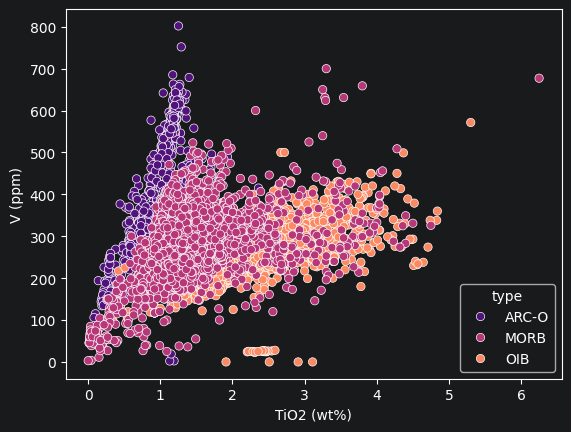

In [9]:
import seaborn as sns

plt.figure()
# Ref: https://matplotlib.org/stable/users/explain/colors/colormaps.html
sns.scatterplot(data=basalt_filt, x='TiO2', y='V', hue='type', palette='magma')
plt.xlabel('TiO2 (wt%)')
plt.ylabel('V (ppm)')
plt.show()

**(5 points)** Use the pandas groupby function to group by affinity and describe the values of column 'TiO2'

In [10]:
basalt_filt.columns

Index(['X1', 'type', 'location', 'SiO2', 'TiO2', 'Al2O3', 'FeOt', 'MgO', 'MnO',
       'CaO', 'Na2O', 'K2O', 'P2O5', 'Ni', 'V', 'Cr', 'Rb', 'Sr', 'Y', 'Zr',
       'Nb', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho',
       'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta', 'Pb', 'Th', 'U'],
      dtype='str')

In [11]:
## Use the groupby and describe methods to get a summary of the TiO2 content for each affinity group
basalt_filt.groupby('type')['TiO2'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
ARC-O,2450.0,1.088476,0.328436,0.08,0.90,1.11,1.29,3.63
MORB,10543.0,1.428800,0.864277,0.00,1.14,1.39,1.63,73.00
OIB,8793.0,2.500914,0.584542,0.03,2.21,2.44,2.73,5.76


Do the same for the column 'V'

In [12]:
## Use the groupby and describe methods to get a summary of the V content for each affinity group
basalt_filt.groupby('type')['V'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
ARC-O,930.0,398.308909,128.512059,2.24,300.1,383.0,500.0,802.0
MORB,3617.0,280.090951,72.059505,3.00,245.0,280.0,320.0,700.0
OIB,2811.0,269.208103,53.322999,0.00,243.0,275.0,296.0,571.5


In [13]:
scaler = StandardScaler()
df_scaled = basalt_filt.copy()
df_scaled[['TiO2', 'V']] = scaler.fit_transform(basalt_filt[['TiO2', 'V']])

stats = df_scaled.groupby('type')[['TiO2', 'V']].agg(['min', 'max'])

for col in ['TiO2', 'V']:
    print(col)
    for t in stats.index:
        t_min = stats.loc[t, (col, 'min')]
        t_max = stats.loc[t, (col, 'max')]
        others = df_scaled[df_scaled['type'] != t]
        overlap_count = ((others[col] >= t_min) & (others[col] <= t_max)).sum()
        print(t,":",overlap_count)


TiO2
ARC-O : 18866
MORB : 11243
OIB : 12978
V
ARC-O : 6424
MORB : 3733
OIB : 4420


*Can you differentiate between the different types on titanium or vanadium concentration alone?*

Yes, titanium has ARC-O, MORB, ORB at least 0.08wt%=800ppm, while vanadium has them

## Exercise 2: A basic linear classification

An approach that has been taken in volcanic geochemistry is to draw lines to use for classification.

We are using the package scikit-learn in order to implement such a classification. Scikit-learn is a widely-used Python library for machine learning and data analysis. It provides a wide range of tools for data preprocessing, model selection, and evaluation. Its user-friendly interface and extensive documentation make it a popular choice for researchers, data analysts, and machine learning practitioners.

<img src="https://scikit-learn.org/stable/_static/scikit-learn-logo-small.png" alt="scikit-learn logo">

**(5 points)** We can use `LogisticRegression` from scikit-learn as a classifier. The algorithm finds the best straight line, also called a hyperplane (in higher dimension data), to separate different groups of data.  Once the lines have been found they can be used predict the group of new data points based on which side of the line they fall on.

In the following cells define the `LogisticRegression` classifier, we then need to prepare the data for classification, to do this let's define a new dataframe `basalt_data_Ti_V` that contains ONLY the rows where BOTH TiO$_2$ and V are not NaN. Once you've done this print the length of the `basalt_filt` DataFrame and the length of the `basalt_data_Ti_V` DataFrame. How many samples were removed by this filtering step?

In [14]:
## Define the classifier using the LogisticRegression class from scikit-learn. Hint: use the 'liblinear' solver
classifier_linear = LogisticRegression(solver='liblinear')

## Let's create a new DataFrame with only the samples that have both TiO2 and V data available. Hint: use the .notna() method
basalt_data_Ti_V = basalt_filt[basalt_filt['TiO2'].notna() & basalt_filt['V'].notna()].copy()

In [15]:
## Print the number of samples in the original DataFrame basalt_data and the new DataFrame basalt_data_Ti_V
print(f"{len(basalt_filt)=}")
print(f"{len(basalt_data_Ti_V)=}")
print(f"{len(basalt_filt) - len(basalt_data_Ti_V)=}")

len(basalt_filt)=21808
len(basalt_data_Ti_V)=7358
len(basalt_filt) - len(basalt_data_Ti_V)=14450


In machine learning literature and code conventions, uppercase "X" is often used to represent the matrix of feature variables (predictors), while lowercase "y" is used to represent the target variable (response).

This notation is used to visually distinguish between the two variables and indicate that "X" is a matrix (usually with multiple columns for features), while "y" is a vector (usually with a single column representing the target variable). 

The uppercase "X" signifies a multi-dimensional data structure, and the lowercase "y" signifies a one-dimensional data structure.

**(5 points)** Define the X and y values for the following classification.

In [16]:
## Let's define X as the features of ['TiO2_wt_percent', 'V_ppm'] and y as the target variable 'affinity'
X = basalt_data_Ti_V[['TiO2', 'V']]
y = basalt_data_Ti_V['type']

The categorical variables that represent different categories that we have here are: 'MORB', 'ARC-O', and 'OIB'. However, most machine learning algorithms require numerical inputs. 

Label encoding is a technique that transforms the categorical variables into numerical labels. We can use the `sklearn.preprocessing` `LabelEncoder` function to do this task for us.

In [17]:
## let's encode the target variable y using the LabelEncoder class from scikit-learn
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Let's take a look at the original 'affinity' categories and the encoded categories.

In [18]:
## Print the original and encoded affinity values. Hint: use the np.unique() function
print(y)
print(y_encoded)

2012     ARC-O
2013     ARC-O
2014     ARC-O
2015     ARC-O
2016     ARC-O
         ...  
29192     MORB
29198     MORB
29200     MORB
29202     MORB
29203     MORB
Name: type, Length: 7358, dtype: str
[0 0 0 ... 1 1 1]


In [19]:
print(np.unique(y))
print(np.unique(y_encoded))

['ARC-O' 'MORB' 'OIB']
[0 1 2]


Now that we have `X` as DataFrame of `['TiO2', 'V']` and `y_encoded` as numerical representation of the categories we can fit the classifier to the data.

To do this, we feed the DataFrame of the data and the array of the classification into a `.fit` function preformed on the classifier object.

**(5 points)** Fit the classification using the `X` and `y_encoded` variables

In [20]:
## Fit the classifier using the fit method with X and y_encoded as arguments
classifier_linear = LogisticRegression(solver='lbfgs', max_iter=1000)
classifier_linear.fit(X, y_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**(15 points)** To visualize the descision boundaries we can make a 101 x 101 grid of x and y values between 0 and the maximum values and perform the classification on this grid. Complete the following code to: (i) create an x-y grid between 0 and the max TiO2 and V values (hint, use `np.meshgrid`) and then flatten this into a 2-column array (columns of TiO2 and V); (ii) use the `classified_linear` object to predict the class for every point on this grid and reshape the grid to be the same size and shape as `xx`; (iii) plot up the results using the `contourf` function from `matplotlib.pyplot`; (iv) add the real data.

/home/itsukikigoshi/.miniforge3/envs/EPS88_Gleeson/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


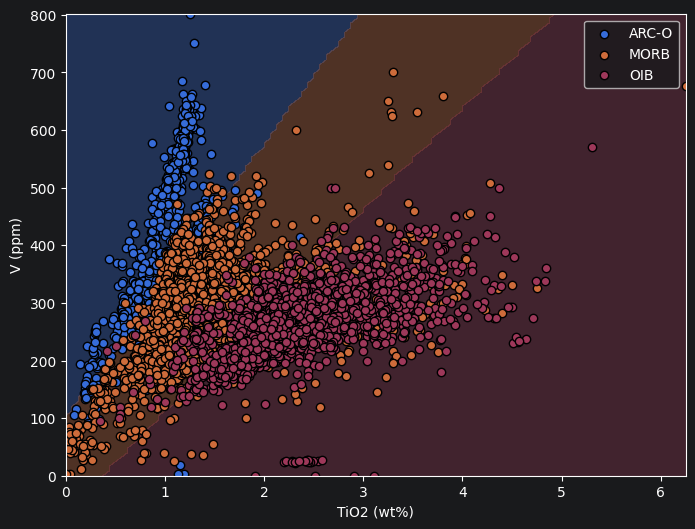

In [21]:
# Generate a grid of points over the feature space
x_min, x_max = 0, X['TiO2'].max()
y_min, y_max = 0, X['V'].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101)) ## create an x-y grid

grid = np.array([xx.ravel(), yy.ravel()]).T ## Flatten the grid

grid = np.array([xx.ravel(), yy.ravel()]).T # classify.predict the grid points
grid_classes = classifier_linear.predict(grid).reshape(xx.shape)  ## reshape the classified grid

cmap = ListedColormap(['C0', 'C1', 'C2']) # Define the colors to make the decision boundary and the data points with the same colors

plt.figure(figsize=(8, 6))

## Plot the decision boundary; Hint: use the plt.contourf() function
plt.contourf(xx, yy, grid_classes, levels=[-1, 0, 1, 2], cmap=cmap, alpha=0.3) # hint use levels = [-1,0,1,2] and cmap = cmap

## Add real data points
for i, name in enumerate(np.unique(y)):
    mask = y == name
    plt.scatter(X.loc[mask, 'TiO2'], X.loc[mask, 'V'], label=name, edgecolors='k', color=f'C{i}')

plt.xlabel('TiO2 (wt%)')
plt.ylabel('V (ppm)')
plt.legend()
plt.show()

## Exercise 3 - Training and testing

How good is our linear classifier? To answer this we'll need to find out how frequently our classifications are correct.

**Discussion question**

*How can we determine the accuracy of this classification scheme using the data that we already have? What other data would be useful in this context?*

#### Why Do We Need to Set Training, Validation, and Test Datasets?

When building a machine learning model, it's crucial to evaluate its performance accurately and ensure it generalizes well to new, unseen data. To achieve this, we typically split our dataset into three parts: training, validation, and test sets.

- The training set is used to train the model. The model learns the patterns and relationships within this data. The goal is to minimize the error on the training set by adjusting the model's parameters.
- The validation set is used to tune the model's hyperparameters. It helps in assessing the model's performance during the training phase and prevents overfitting. By evaluating the model on the validation set, we can choose the best model configuration (there is an example of this shown at the bottom of the notebook).
- The test set is used to evaluate the final model's performance. It provides an unbiased estimate of how well the model will perform on new, **unseen** data. The test set should only be used once the model is fully trained and all hyperparameters are tuned.

#### Variance and Bias Trade-Off

In machine learning, the variance and bias trade-off is a fundamental concept that affects model performance.

- Bias refers to the error introduced by approximating a real-world problem, which may be complex, by a simplified model. High bias can cause the model to miss relevant relations between features and target outputs (underfitting).
- Variance refers to the error introduced by the model's sensitivity to small fluctuations in the training set. High variance can cause the model to model the random noise in the training data rather than the intended outputs (overfitting).

**Trade-Off**:
- **High Bias, Low Variance:** The model is too simple and cannot capture the underlying patterns of the data (underfitting).
- **Low Bias, High Variance:** The model is too complex and captures noise in the training data (overfitting).
- **Optimal Balance:** The goal is to find a balance where the model has low bias and low variance, meaning it generalizes well to new data (see the example at the bottom of this notebook for how this might be done).

By using training, validation, and test sets, we can monitor and adjust our model to achieve this balance, ensuring it performs well on unseen data. In this case we're going to split our data into a 'training' and 'validation' dataset (although we'll use the term 'test') - why does this not represent a true test dataset? 

Let's try it in our classification problem.


Because we are using a linear classifier, there are not many hyperparameters to tune. For simplicity, we will only divide the data into training and testing sets, using 70% of the data for training and 30% for testing.

**(5 points)** Use the `train_test_split` function from `sklearn` to split the data into a 70:30 test:validation split.


In [23]:
## Let's split the data into training and testing sets using the train_test_split function from scikit-learn with a test size of 30%
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42) # Don't Panic!!

In [24]:
## Print the number of samples in the training and testing sets
print(len(X_train))
print(len(X_test))

5150
2208


**(5 points)** Fit the model to the training data. Create a new `LogisticRegression` object called `train_linear` and fit this using the training data.

In [25]:
## Fit the classifier using the training data
train_linear = LogisticRegression(solver='lbfgs', max_iter=1000)
train_linear.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

The validation set was held back from training. We can use it to provide an initial evaluation of the model. How often are the categorizations correction? To do this evaluation, we can predict the categories using `classifier_svc_linear.predict()` and the compare those to the actual labels using `accuracy_score()`

**(10 points)** Create a `y_pred` valiable using the `.predict` method on the `train_linear` object. This should represent the predicted classes for the validation dataset we created above (i.e., use `X_test` as the input). After this calculate and print the accuracy of the classifier (the `accuracy_score` computes the proportion of correct predictions out of the total number of predictions):

In [28]:
## Make predictions on the test set
y_pred = train_linear.predict(X_test)

In [29]:
## Calculate the accuracy using the accuracy_score function
accuracy = accuracy_score(y_test, y_pred)

print(f"{accuracy=}")

accuracy=0.8605072463768116


**(10 points)** Recreate the `contourf` plot from above where we showed the predicted boundaries using a x-y grid (you will need to use the new classification model to predict the 'type' for the x-y grid again). Add the validation data to this plot (don't plot the training data). The fraction of points that are plotting within the correct classification corresponds to the accuracy score. How well did the classification do?

/home/itsukikigoshi/.miniforge3/envs/EPS88_Gleeson/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


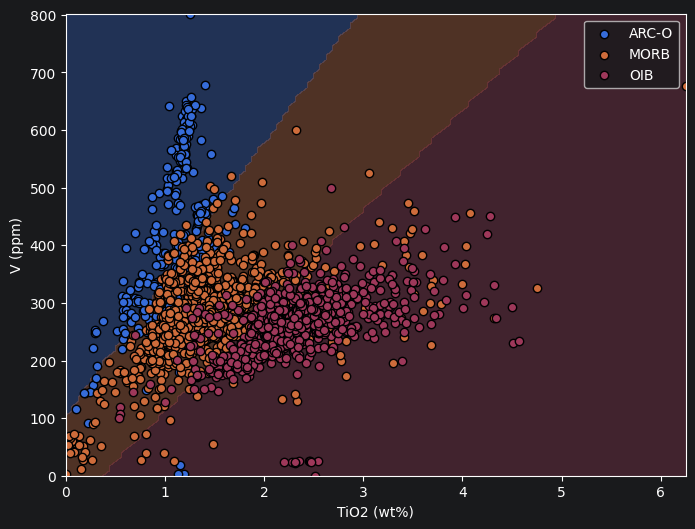

In [31]:
x_min, x_max = 0, X['TiO2'].max()
y_min, y_max = 0, X['V'].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

grid = np.array([xx.ravel(), yy.ravel()]).T
grid_classes = train_linear.predict(grid)
grid_classes = grid_classes.reshape(xx.shape)

cmap = ListedColormap(['C0', 'C1', 'C2'])

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, grid_classes, levels=[-1, 0, 1, 2], cmap=cmap, alpha=0.3)

for i, label in enumerate(np.unique(y_encoded)):
    mask = y_test == label
    plt.scatter(X_test.iloc[mask, 0], X_test.iloc[mask, 1], label=np.unique(y)[i], edgecolors='k', color=f'C{i}')

plt.xlabel('TiO2 (wt%)')
plt.ylabel('V (ppm)')
plt.legend()
plt.show()

We can visualize the accuracy of the classified using a condution matrix. A confusion matrix is a table that is used to evaluate the performance of a classification algorithm. It visually displays the accuracy of a classifier by comparing its predicted labels against the true labels. The matrix consists of rows and columns that represent the true and predicted classes, respectively. Each cell in the matrix corresponds to the number of samples for a specific combination of true and predicted class labels.

The main diagonal of the matrix represents the correctly classified instances, while the off-diagonal elements represent the misclassified instances. By analyzing the confusion matrix, you can gain insights into the performance of the classifier and identify where it gets "confused."

**(5 points)** Complete the code below to plot the confusion matrix.

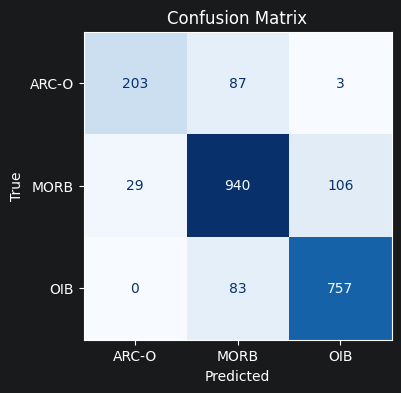

In [32]:
## Calculate the confusion matrix using the confusion_matrix function
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
class_names = le.inverse_transform(np.unique(y_test)).astype(str)

## Plot the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.show()


Can you interpret the confusion matrix? What does it tell you about the performance of the classifier?

We have not so many false positive/nigetives (87+3+29+106+0+83) out of the data size.

## Exercise 4 - Descision Trees

What we've done so far is relatively simplistic (compared to other machine learning approaches) and only uses a small amount of the available data (only 2 variables!). In the rest of this notebook we'll explore a few other machine learning options and expand the data we'll using in these classifications. Here's a (incomplete) list of classification based machines learning methods.

#### 📚 Commonly Used Classification Methods in Machine Learning

---

🔹 Classical (Statistical / Simple) Models
1. **Logistic Regression**  
   - Great baseline model, especially for binary classification.
2. **Linear Discriminant Analysis (LDA)**  
   - Projects data to a lower dimension for class separation.
3. **Quadratic Discriminant Analysis (QDA)**  
   - Like LDA, but allows each class to have its own covariance matrix.

---

🔸 Tree-Based and Ensemble Methods
1. **Decision Trees**  
   - Easy to interpret; splits data on features.
2. **Random Forest**  
   - Ensemble of decision trees; reduces overfitting.
3. **Gradient Boosting Machines (GBM)**  
   - Sequentially builds trees to fix previous errors.

---

🔹 Support Vector Machines (SVM)
- Works well for both linear and non-linear classification.

---

🔸 Neural Network-Based
1. **Multilayer Perceptrons (MLP)**  
   - Basic feedforward networks.
2. **Convolutional Neural Networks (CNNs)**  
   - Excellent for image data.
3. **Recurrent Neural Networks (RNNs), LSTMs, GRUs**  
   - Used for sequential data like time series or text.
4. **Transformers / BERT / GPT**  
   - State-of-the-art for NLP classification tasks.

---

🔹 Probabilistic / Bayesian Methods
1. **Bayesian Networks**
2. **Gaussian Mixture Models (with classification on top)**



**(10 points)** First let's prepare the data to use features other than TiO2 and V. We'll repeat some of the processes from above to do this (this isn't strictly necessary as some variables are already defined, but good practice nonetheless!)

1. Split the data into features (X) and target (y): The dataset is split into two parts, features (X) and the target variable (y). Features are the input variables that the classifier will use to make predictions, and the target variable is the output we want the classifier to predict.

2. Encode the target variable 'type' using LabelEncoder: The target variable 'type' contains categorical data, which needs to be encoded as numerical values for the decision tree classifier. The LabelEncoder from scikit-learn is used to transform the 'affinity' column into numerical labels.

3. Impute missing values using median imputation: most classifiers cannot handle missing values in the input data. Therefore, missing values in the dataset need to be imputed (filled in) before training the classifier. Let's use median imputation which replaces the missing values with the median of the non-missing values in the same column. We can import and use the `SimpleImputer` function.

In [34]:
## Prepare the data into features (X) and target (y)
X = basalt_filt.select_dtypes(include=[np.number])
y = basalt_filt['type']

## We will keep the column names for later use
columns = X.columns

## Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## Impute missing values using median imputation
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

## Split the data into training and test sets using 30% of the data for testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

Let's try a **Decision Trees** approach which is another supervised machine learning algorithm for classification 

**Decision Trees** are a type of flowchart-like structure where internal nodes represent decisions based on the input features, branches represent the outcome of these decisions, and leaf nodes represent the final output or class label. The primary goal of a decision tree is to recursively split the data into subsets based on feature values that maximize the separation between the classes.

*Why use Decision Trees?*

- Easy to understand and interpret: Decision Trees are human-readable and can be visualized, making them easy to understand and interpret even for those with limited machine learning experience.
- Minimal data preprocessing: Decision Trees do not require extensive data preprocessing, such as scaling or normalization, as they can handle both numerical and categorical features.
- Non-linear relationships: Decision Trees can model complex, non-linear relationships between features and target variables.
- Feature importance: Decision Trees can provide insights into feature importance, helping to identify the most relevant features for the problem at hand.

**(10 points)** Using the `DescisionTreeClassifier` class from `sklearn` (this has already been imported into our Python environment) define a classifier, train (`.fit`) the classifier using the training data, make predictions for the validation (training) data, and calculate the accuracy of the classifier used.

In [35]:
## Define the decision tree classifier
classifier = DecisionTreeClassifier(random_state=42)

## Train the model
classifier.fit(X_train, y_train)

## Make predictions on the test set
y_pred = classifier.predict(X_test)
## Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"{accuracy=}")

accuracy=0.9700443221763717


**(5 points)** Create a confusion matrix for this classifier

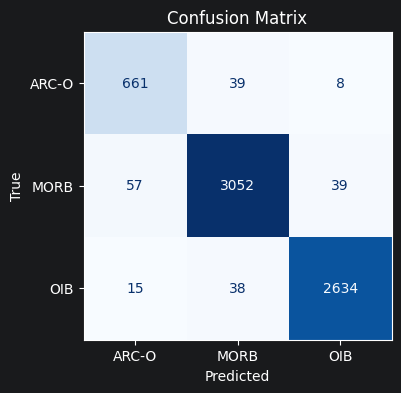

In [36]:
## Calculate the confusion matrix using the confusion_matrix function
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
class_names = le.inverse_transform(np.unique(y_test)).astype(str)

## Plot the confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d', colorbar=False)

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.show()


**(5 points)** There are a couple more things that we can do to examine this model. First for Descision Tree classifiers we can usually plot the 'Descision Tree' itself. This represents a sort of 'flow-chart' structure, indicating which descisions are taken at different levels to classify the data.

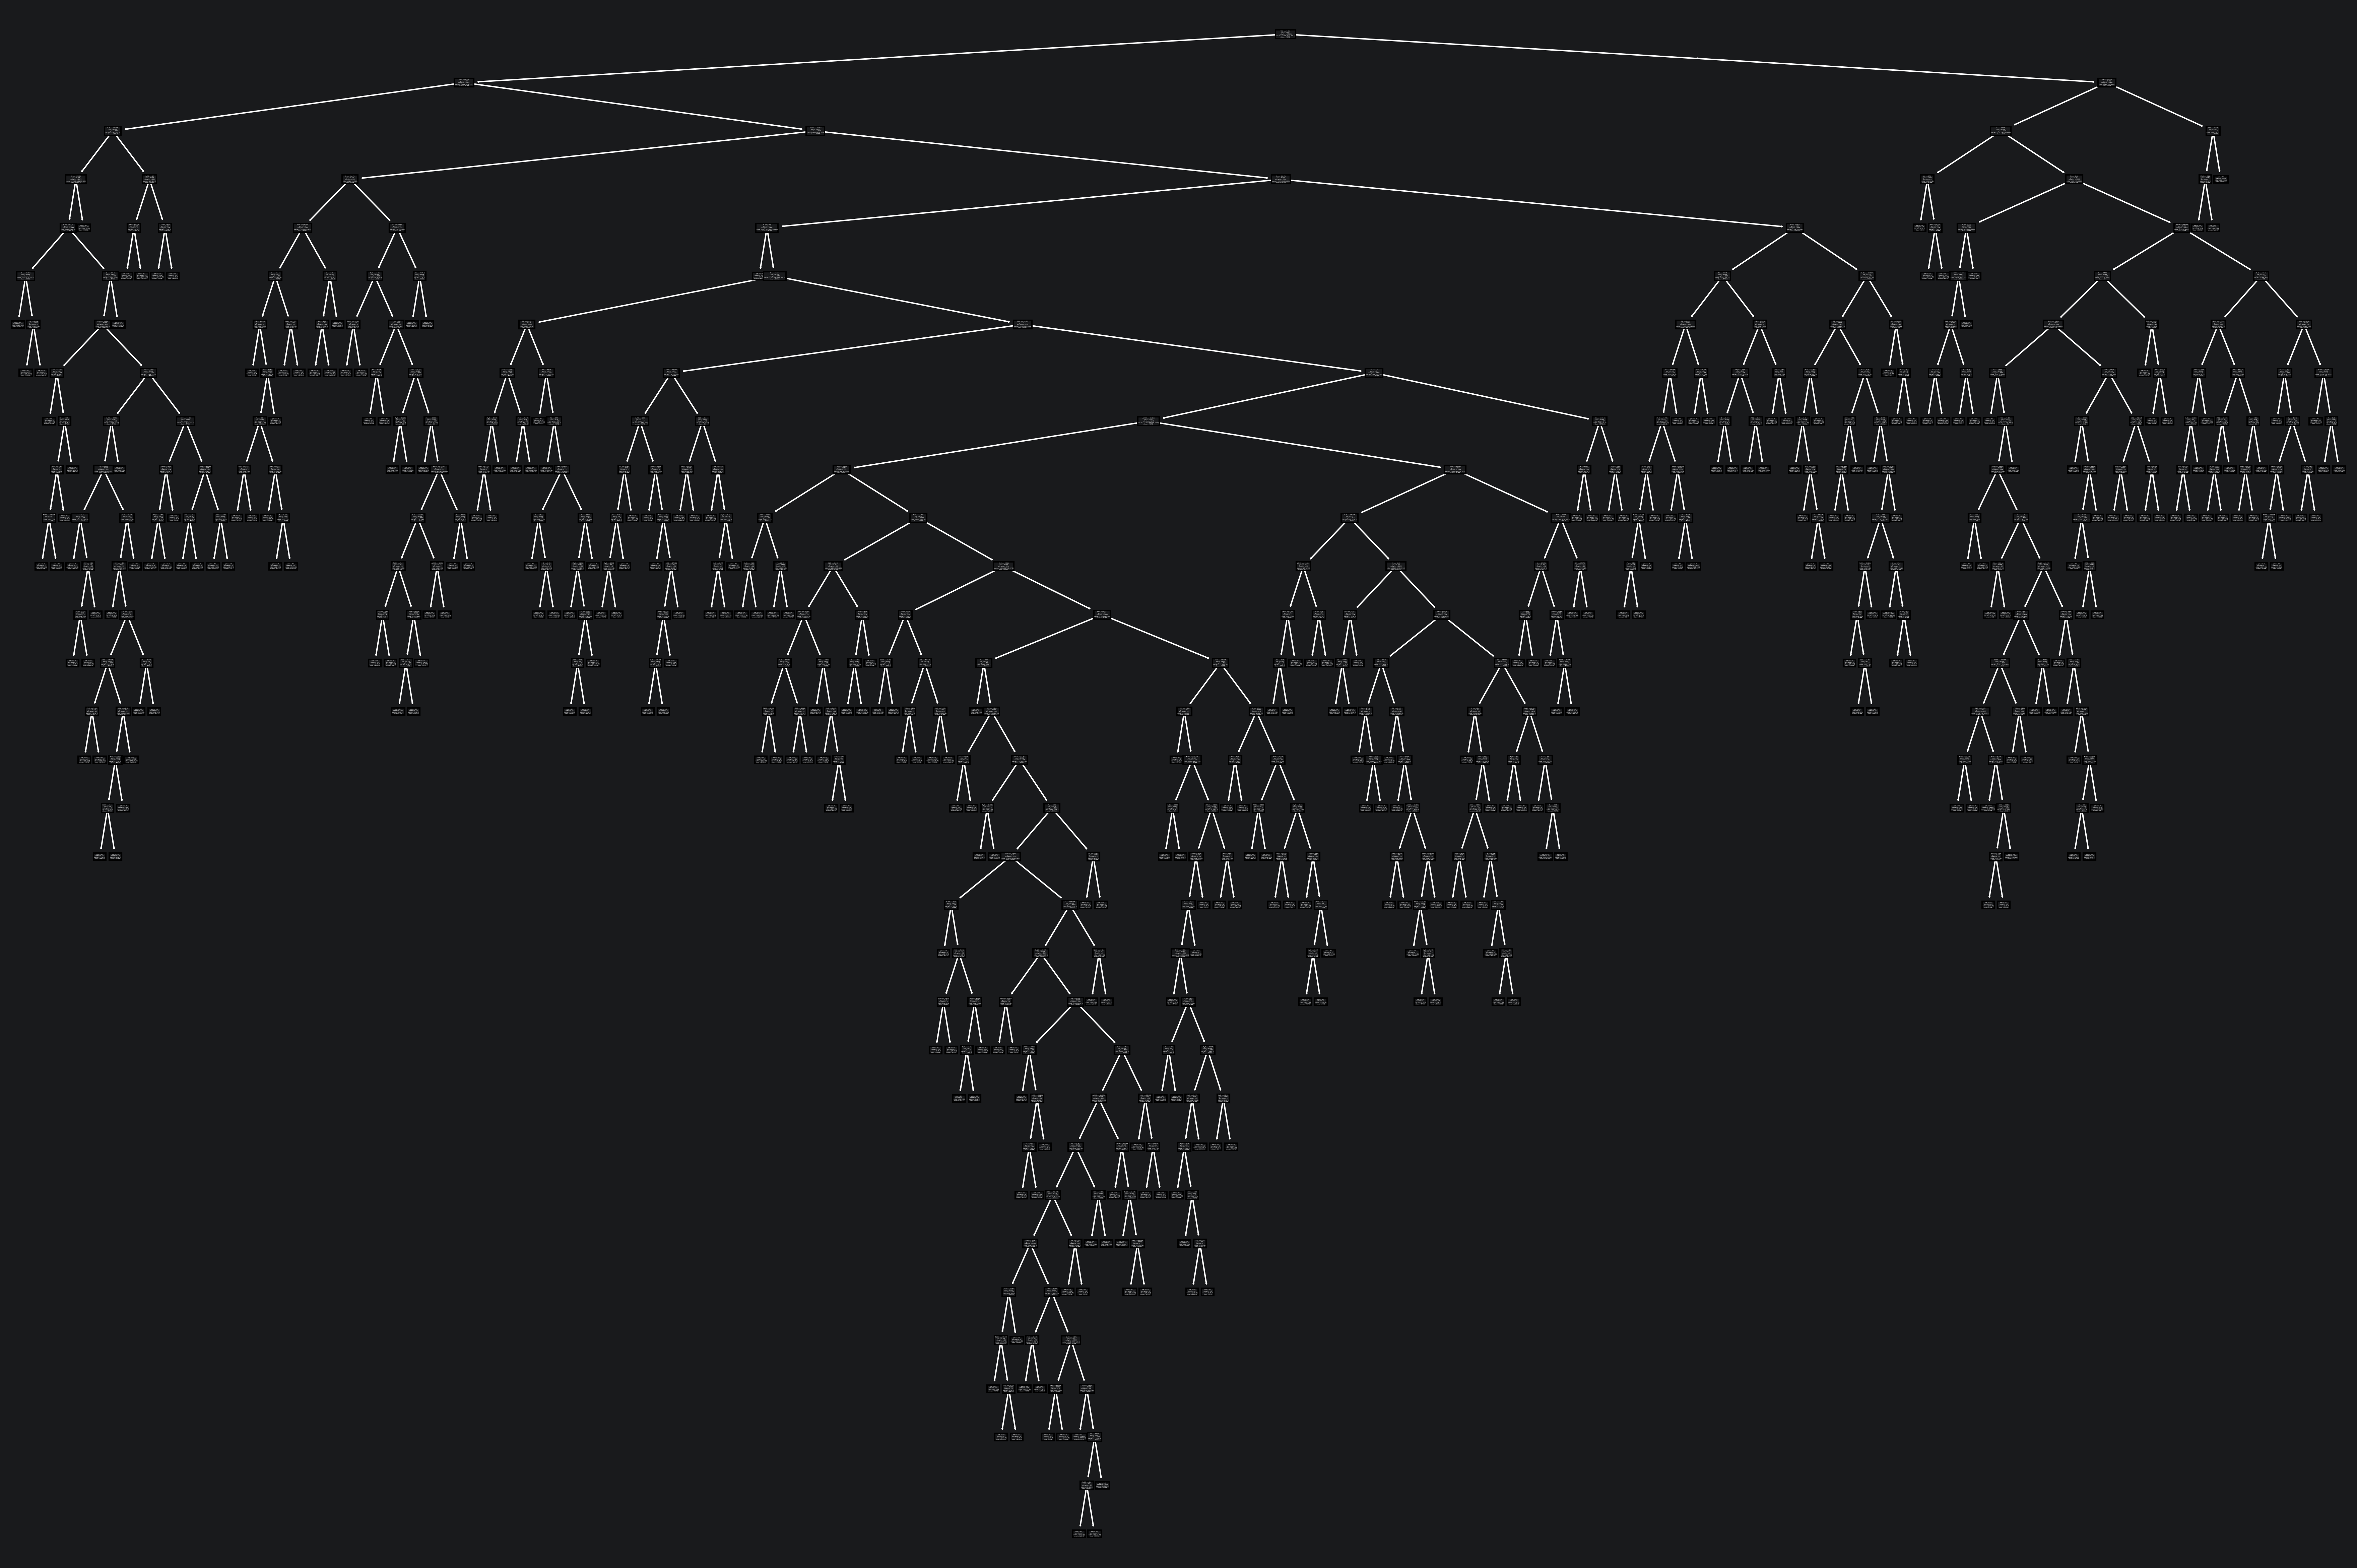

In [39]:
fig, ax = plt.subplots(figsize=(30, 20), dpi = 300)

## Get the original class names
class_names = le.inverse_transform(np.unique(y_train)).astype(str)

## Visualize the decision tree
plot_tree(classifier,
          feature_names=columns,
          class_names=class_names,
          ax=ax)

plt.show()

We can also ask the question 'what data is most important'? Essentially, we want to be able to readily determine what data fields are the most important for the decision tree. We can do that by determining "feature importance." The code below extracts and displays the importance score, also known as Gini importance or Mean Decrease Impurity, which is a measure of how much a feature contributes to the decision-making process of the decision tree model. 

In [38]:
## Get the feature importances from the classifier
importances = classifier.feature_importances_

## Pair the feature names with their corresponding importances
feature_importances = list(zip(columns, importances))

## Create a DataFrame from the feature importances
df_feature_importances = pd.DataFrame(feature_importances, columns=['Feature', 'Importance'])

## Sort the feature importances in descending order
df_feature_importances = df_feature_importances.sort_values(by='Importance', ascending=False)

## Reset the index and drop the old index column
df_feature_importances.reset_index(drop=True, inplace=True)

## Display the sorted feature importances
display(df_feature_importances)

,Feature,Importance
0,TiO2,0.458127
1,MgO,0.134882
2,X1,0.107442
3,Al2O3,0.085268
4,Sr,0.049291
5,Zr,0.030434
6,FeOt,0.022689
7,CaO,0.019338
8,Ni,0.014695
9,SiO2,0.011188


## BONUS - Support Vector Machines (SVM)

#### What is a support vector machine?

Support vector machines are a type of supervised learning model that can be used for both classification and regression. The basic idea is to find the hyperplane that best separates the classes in the feature space. The hyperplane is defined by the support vectors, which are the points that are closest to the hyperplane. The distance between the support vectors and the hyperplane is called the margin. The goal of the SVM is to maximize the margin, which is done by minimizing the norm of the weight vector. The SVM can be used for both linear and non-linear classification by using different kernel functions.

#### How does the SVM work?

Support vector machines work by finding the hyperplane that best separates the classes in the feature space. The hyperplane is defined by the support vectors, which are the points that are closest to the hyperplane. The distance between the support vectors and the hyperplane is called the margin. The goal of the SVM is to maximize the margin, which is done by minimizing the norm of the weight vector. The SVM can be used for both linear and non-linear classification by using different kernel functions.

<!-- ![](images/SVM-basic.png) -->
<img src="figures/SVM-basic.png" >

#### What is a kernel function?

A kernel function is a function that takes two input vectors and returns a scalar value. The kernel function is used to map the input vectors into a higher-dimensional space where the classes are linearly separable. The most common kernel functions are the linear kernel, the polynomial kernel, and the radial basis function (RBF) kernel.

<!-- ![](images/SVM-kernel.png) -->
<img src="figures/SVM-kernel.png" >

*Let's try a support vector machine classifier for our data.* First, we will use a linear kernel to classify the data. Same as before, we will use the `SVC` class from the `sklearn.svm` module. We will use the `fit` method to train the model on the training data and the `predict` method to make predictions on the test data.

Accuracy: 0.96


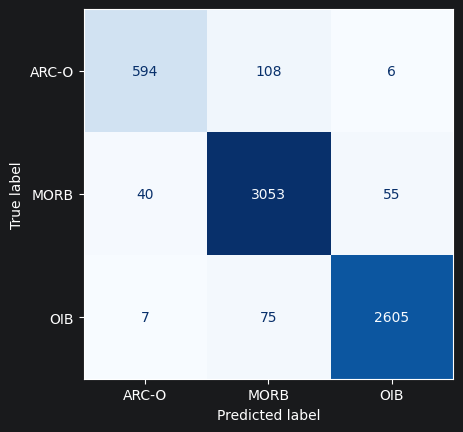

In [40]:
## Define the classifier using make_pipeline
classifier = make_pipeline(StandardScaler(), SVC(kernel="linear"))

## Train the model
classifier.fit(X_train, y_train)

## Predict the test set
y_pred = classifier.predict(X_test)

## Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

## Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d', colorbar=False)

Let's try to classify the data using a non-linear kernel. We will use the radial basis function (RBF) kernel, which is the default kernel for the `SVC` class. The RBF kernel is defined as:

$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$

where $\gamma$ is a hyperparameter that controls the smoothness of the decision boundary. A larger value of $\gamma$ will result in a more complex decision boundary, which can lead to overfitting. We will use the default value of $\gamma$ for now, but we can tune it later if needed.

Accuracy: 0.98


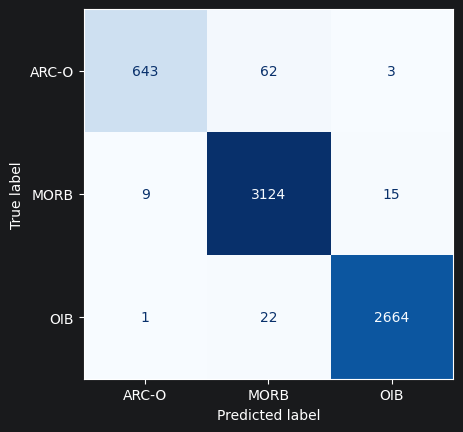

In [41]:
## Define the classifier using make_pipeline and the RBF kernel
gamma = 0.03 ## gamma is a hyperparameter of the RBF kernel
classifier = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma = gamma))

## Train the model
classifier.fit(X_train,y_train)

## Predict the test set
y_pred = classifier.predict(X_test)

## Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

## Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d', colorbar=False)

Remember from the lecture when we discussed bias (underfitting) and variance (overfitting). We can demonstrate that here by systematically adjusting the $\gamma$ hyperparameter and examining how this influences the accuracy score for the validation dataset (and also the original training dataset). What you should see when you run the code below is that the accuracy of the classifier increases with increasing $\gamma$ up until $\gamma = 0.08$. Beyond this point the accuracy score for the training dataset continues to increase, but the accuracy score for the validation dataset decreases. This indicates that for greater values of $\gamma$ we are overfitting the training data (i.e., fitting the noise in the data) so when new data is introduce the model does a poor job in classifying the data.

Only AFTER running this analysis to determine the optimal $\gamma$ value would we introduce a true 'Test' dataset to evalate our model.

In [ ]:
def train_svm_and_get_accuracies(gamma, X_train, y_train, X_test, y_test):

    classifier = make_pipeline(StandardScaler(), SVC(kernel="rbf", gamma=gamma))
    classifier.fit(X_train, y_train)
    
    # Calculate accuracies
    train_accuracy = accuracy_score(y_train, classifier.predict(X_train))
    test_accuracy = accuracy_score(y_test, classifier.predict(X_test))
    
    return train_accuracy, test_accuracy

# Generate a range of gamma values
gamma_values = np.logspace(-4, 1, 20)

# Lists to store accuracies
train_accuracies = []
test_accuracies = []

# Calculate accuracies for each gamma value
for gamma in gamma_values:
    train_acc, test_acc = train_svm_and_get_accuracies(gamma, X_train, y_train, X_test, y_test)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot accuracy vs gamma
plt.figure(figsize=(12, 8))
plt.semilogx(gamma_values, train_accuracies, label='Training Accuracy', marker='o')
plt.semilogx(gamma_values, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Gamma')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Gamma (SVM with RBF Kernel)')
plt.legend()
plt.grid(True)

idx = np.argmax(test_accuracies)
best_gamma = gamma_values[idx]
plt.axvline(x=best_gamma, color='r', linestyle='--', label=f'Best Gamma: {best_gamma:.2f}\nTraining Accuracy: {train_accuracies[idx]:.2f}\nTest Accuracy: {test_accuracies[idx]:.2f}')
plt.text(10**((-3 + np.log10(best_gamma)) / 2), 0.7, 'High Bias\nUnderfitting', ha='center')
plt.text(10**((1 + np.log10(best_gamma)) / 2), 0.7, 'High Variance\nOverfitting', ha='center')

plt.legend()
plt.show()